# 12 — Multi-Feature CNN (Main Deep-Learning Experiment)

Uses three complementary channels: Mel spectrogram, MFCC, and chroma. The same patient-wise split, compact architecture, training-only augmentation, validation early stopping, and class-weighted loss are used as in the one-channel baseline. Compare macro F1 and per-class performance, not accuracy alone.

In [1]:
from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import soundfile as sf
import librosa

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("PyTorch version:", torch.__version__)
print("Librosa version:", librosa.__version__)

PyTorch version: 2.14.1
Librosa version: 1.0.0


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:", device)

Selected device: mps


In [3]:
PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DL_DIR = PROCESSED_DIR / "deep_learning"

BASELINE_DIR = DL_DIR / "cnn_baseline"

MULTIFEATURE_DIR = DL_DIR / "multifeature_cnn"
MULTIFEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Deep learning directory:", DL_DIR)
print("Multi-feature output:", MULTIFEATURE_DIR)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Deep learning directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning
Multi-feature output: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [5]:
TARGET_SR = 4000
TARGET_DURATION = 5.0
TARGET_SAMPLES = int(
    TARGET_SR * TARGET_DURATION
)

N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64

FMIN = 0
FMAX = 2000

print("Target SR:", TARGET_SR)
print("Target duration:", TARGET_DURATION)
print("Target samples:", TARGET_SAMPLES)
print("N_FFT:", N_FFT)
print("Hop length:", HOP_LENGTH)
print("Mel bands:", N_MELS)
print("Frequency range:", FMIN, "-", FMAX, "Hz")

Target SR: 4000
Target duration: 5.0
Target samples: 20000
N_FFT: 512
Hop length: 128
Mel bands: 64
Frequency range: 0 - 2000 Hz


In [6]:
class_mapping_path = (
    DL_DIR / "disease_class_mapping.csv"
)

class_mapping = pd.read_csv(
    class_mapping_path
)

class_names = (
    class_mapping
    .sort_values("disease_label")["diagnosis"]
    .tolist()
)

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

Number of classes: 8
Classes:
0 -> Asthma
1 -> Bronchiectasis
2 -> Bronchiolitis
3 -> COPD
4 -> Healthy
5 -> LRTI
6 -> Pneumonia
7 -> URTI


In [7]:
train_manifest_path = (
    BASELINE_DIR /
    "train_cnn_manifest.csv"
)

val_manifest_path = (
    BASELINE_DIR /
    "validation_cnn_manifest.csv"
)

test_manifest_path = (
    BASELINE_DIR /
    "test_cnn_manifest.csv"
)

train_manifest = pd.read_csv(
    train_manifest_path
)

val_manifest = pd.read_csv(
    val_manifest_path
)

test_manifest = pd.read_csv(
    test_manifest_path
)

print("Train:", train_manifest.shape)
print("Validation:", val_manifest.shape)
print("Test:", test_manifest.shape)

Train: (4423, 8)
Validation: (914, 8)
Test: (1561, 8)


In [8]:
train_patients = set(
    train_manifest["patient_id"]
)

val_patients = set(
    val_manifest["patient_id"]
)

test_patients = set(
    test_manifest["patient_id"]
)

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("\nPatient-disjoint split verified.")

Train patients: 82
Validation patients: 19
Test patients: 25

Patient-disjoint split verified.


In [9]:
for name, manifest in [
    ("train", train_manifest),
    ("validation", val_manifest),
    ("test", test_manifest)
]:
    assert manifest["disease_label"].notna().all()

    labels = set(
        manifest["disease_label"].astype(int)
    )

    assert labels.issubset(
        set(range(num_classes))
    )

    print(
        f"{name}: "
        f"{len(manifest)} cycles, "
        f"{manifest['patient_id'].nunique()} patients"
    )

train: 4423 cycles, 82 patients
validation: 914 cycles, 19 patients
test: 1561 cycles, 25 patients


In [10]:
def fix_audio_length(signal, target_samples):
    if len(signal) < target_samples:
        signal = np.pad(
            signal,
            (0, target_samples - len(signal)),
            mode="constant"
        )
    else:
        signal = signal[:target_samples]

    return signal.astype(np.float32)

In [11]:
def load_processed_audio(audio_path):
    signal, sr = sf.read(audio_path)

    if signal.ndim > 1:
        signal = np.mean(signal, axis=1)

    if sr != TARGET_SR:
        raise ValueError(
            f"Expected {TARGET_SR} Hz, got {sr} Hz"
        )

    signal = signal.astype(np.float32)

    signal = fix_audio_length(
        signal,
        TARGET_SAMPLES
    )

    return signal

In [12]:
def extract_logmel(signal):
    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel_power,
        ref=np.max
    )

    return mel_db.astype(np.float32)

In [13]:
N_MFCC = 13

def extract_mfcc(signal):
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=TARGET_SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        fmax=FMAX
    )

    return mfcc.astype(np.float32)

In [19]:
N_CHROMA = 12

def extract_chroma(signal):
    chroma = librosa.feature.chroma_stft(
        y=signal,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_chroma=N_CHROMA,
        tuning=0.0
    )

    return chroma.astype(np.float32)

In [20]:
sample_audio_path = train_manifest.iloc[0]["audio_path"]

sample_logmel, sample_mfcc, sample_chroma = (
    extract_multifeature_representation(
        sample_audio_path
    )
)

print("Audio:", sample_audio_path)

print("\nLog-Mel shape:", sample_logmel.shape)
print("MFCC shape:", sample_mfcc.shape)
print("Chroma shape:", sample_chroma.shape)

print("\nLog-Mel range:",
      sample_logmel.min(),
      "to",
      sample_logmel.max())

print("MFCC range:",
      sample_mfcc.min(),
      "to",
      sample_mfcc.max())

print("Chroma range:",
      sample_chroma.min(),
      "to",
      sample_chroma.max())

Audio: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/102/1b1_Ar_001.wav

Log-Mel shape: (64, 157)
MFCC shape: (13, 157)
Chroma shape: (12, 157)

Log-Mel range: -80.0 to 0.0
MFCC range: -584.3461 to 140.9968
Chroma range: 0.0 to 1.0


In [21]:
assert sample_logmel.shape == (64, 157)
assert sample_mfcc.shape == (13, 157)
assert sample_chroma.shape == (12, 157)

assert np.isfinite(sample_logmel).all()
assert np.isfinite(sample_mfcc).all()
assert np.isfinite(sample_chroma).all()

print("All three feature representations are valid.")

All three feature representations are valid.


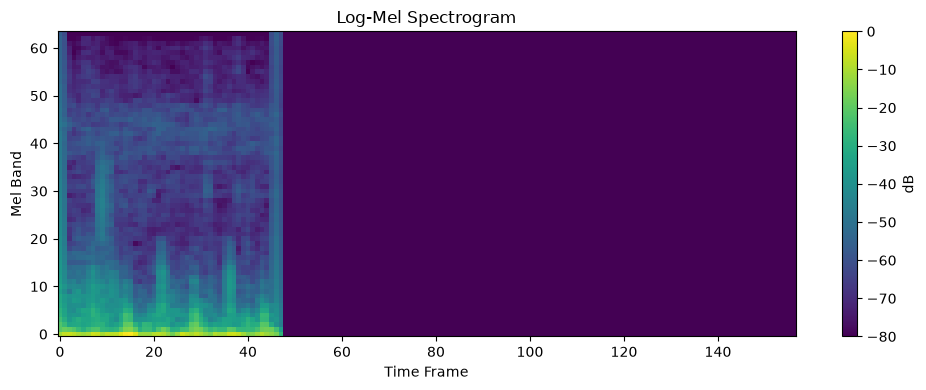

In [22]:
plt.figure(figsize=(10, 4))

plt.imshow(
    sample_logmel,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="dB")
plt.xlabel("Time Frame")
plt.ylabel("Mel Band")
plt.title("Log-Mel Spectrogram")

plt.tight_layout()
plt.show()

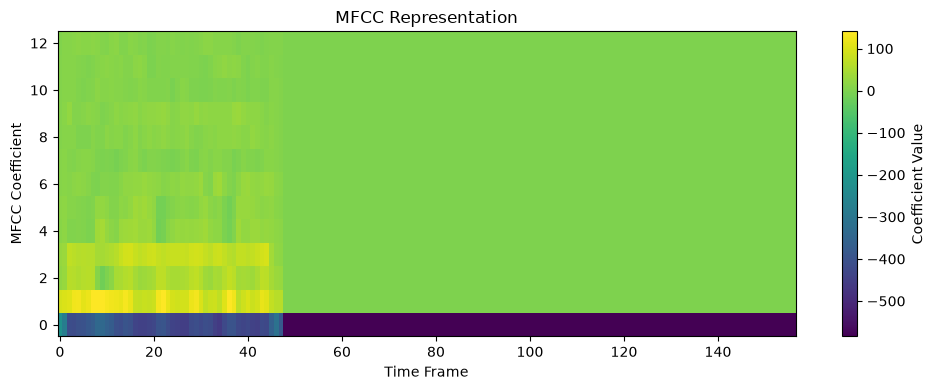

In [23]:
plt.figure(figsize=(10, 4))

plt.imshow(
    sample_mfcc,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Coefficient Value")
plt.xlabel("Time Frame")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Representation")

plt.tight_layout()
plt.show()

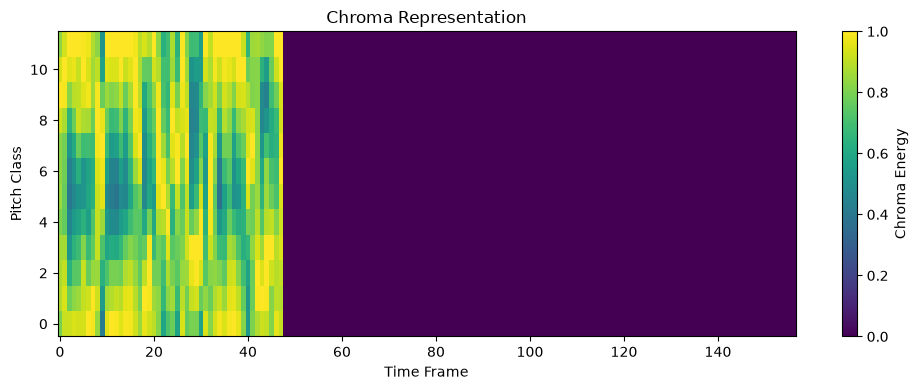

In [24]:
plt.figure(figsize=(10, 4))

plt.imshow(
    sample_chroma,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Chroma Energy")
plt.xlabel("Time Frame")
plt.ylabel("Pitch Class")
plt.title("Chroma Representation")

plt.tight_layout()
plt.show()

In [25]:
print("Log-Mel time frames:", sample_logmel.shape[1])
print("MFCC time frames:", sample_mfcc.shape[1])
print("Chroma time frames:", sample_chroma.shape[1])

assert sample_logmel.shape[1] == sample_mfcc.shape[1]
assert sample_logmel.shape[1] == sample_chroma.shape[1]

print("\nTemporal alignment verified.")

Log-Mel time frames: 157
MFCC time frames: 157
Chroma time frames: 157

Temporal alignment verified.


In [26]:
feature_stats = {
    "logmel": {
        "count": 0,
        "sum": 0.0,
        "sum_sq": 0.0
    },
    "mfcc": {
        "count": 0,
        "sum": 0.0,
        "sum_sq": 0.0
    },
    "chroma": {
        "count": 0,
        "sum": 0.0,
        "sum_sq": 0.0
    }
}

print("Running statistics initialized.")

Running statistics initialized.


In [27]:
for i, audio_path in enumerate(
    train_manifest["audio_path"]
):

    signal = load_processed_audio(audio_path)

    logmel = extract_logmel(signal)
    mfcc = extract_mfcc(signal)
    chroma = extract_chroma(signal)

    for name, feature in [
        ("logmel", logmel),
        ("mfcc", mfcc),
        ("chroma", chroma)
    ]:
        values = feature.astype(np.float64)

        feature_stats[name]["count"] += values.size
        feature_stats[name]["sum"] += values.sum()
        feature_stats[name]["sum_sq"] += np.square(
            values
        ).sum()

    if (i + 1) % 500 == 0:
        print(
            f"Processed {i + 1}/"
            f"{len(train_manifest)} training cycles"
        )

print("Training feature statistics collected.")

Processed 500/4423 training cycles
Processed 1000/4423 training cycles
Processed 1500/4423 training cycles
Processed 2000/4423 training cycles
Processed 2500/4423 training cycles
Processed 3000/4423 training cycles
Processed 3500/4423 training cycles
Processed 4000/4423 training cycles
Training feature statistics collected.


In [28]:
normalization_records = []

for feature_name, stats in feature_stats.items():

    count = stats["count"]
    total = stats["sum"]
    total_sq = stats["sum_sq"]

    mean = total / count

    variance = (
        total_sq / count
        - mean ** 2
    )

    variance = max(
        variance,
        0.0
    )

    std = np.sqrt(variance)

    normalization_records.append({
        "feature": feature_name,
        "count": count,
        "mean": mean,
        "std": std
    })

normalization_df = pd.DataFrame(
    normalization_records
)

display(normalization_df)

,feature,count,mean,std
0,logmel,44442304,-66.230481,17.661886
1,mfcc,9027343,-22.509034,137.274416
2,chroma,8332932,0.385656,0.389059


In [29]:
assert len(normalization_df) == 3

assert set(
    normalization_df["feature"]
) == {
    "logmel",
    "mfcc",
    "chroma"
}

assert np.isfinite(
    normalization_df["mean"]
).all()

assert np.isfinite(
    normalization_df["std"]
).all()

assert (
    normalization_df["std"] > 0
).all()

print("Normalization statistics are valid.")

Normalization statistics are valid.


In [30]:
logmel_mean = float(
    normalization_df.loc[
        normalization_df["feature"] == "logmel",
        "mean"
    ].iloc[0]
)

logmel_std = float(
    normalization_df.loc[
        normalization_df["feature"] == "logmel",
        "std"
    ].iloc[0]
)

mfcc_mean = float(
    normalization_df.loc[
        normalization_df["feature"] == "mfcc",
        "mean"
    ].iloc[0]
)

mfcc_std = float(
    normalization_df.loc[
        normalization_df["feature"] == "mfcc",
        "std"
    ].iloc[0]
)

chroma_mean = float(
    normalization_df.loc[
        normalization_df["feature"] == "chroma",
        "mean"
    ].iloc[0]
)

chroma_std = float(
    normalization_df.loc[
        normalization_df["feature"] == "chroma",
        "std"
    ].iloc[0]
)

print("Log-Mel:")
print("  mean:", logmel_mean)
print("  std :", logmel_std)

print("\nMFCC:")
print("  mean:", mfcc_mean)
print("  std :", mfcc_std)

print("\nChroma:")
print("  mean:", chroma_mean)
print("  std :", chroma_std)

Log-Mel:
  mean: -66.23048066283803
  std : 17.66188607911125

MFCC:
  mean: -22.509034445067375
  std : 137.27441615628354

Chroma:
  mean: 0.3856557201130974
  std : 0.38905858480534755


In [31]:
normalization_path = (
    MULTIFEATURE_DIR /
    "multifeature_train_normalization.csv"
)

normalization_df.to_csv(
    normalization_path,
    index=False
)

print("Saved normalization statistics to:")
print(normalization_path)

Saved normalization statistics to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_train_normalization.csv


In [32]:
normalized_logmel = (
    sample_logmel - logmel_mean
) / logmel_std

normalized_mfcc = (
    sample_mfcc - mfcc_mean
) / mfcc_std

normalized_chroma = (
    sample_chroma - chroma_mean
) / chroma_std

print("Normalized Log-Mel:")
print(
    "mean =", normalized_logmel.mean(),
    "std =", normalized_logmel.std()
)

print("\nNormalized MFCC:")
print(
    "mean =", normalized_mfcc.mean(),
    "std =", normalized_mfcc.std()
)

print("\nNormalized Chroma:")
print(
    "mean =", normalized_chroma.mean(),
    "std =", normalized_chroma.std()
)

Normalized Log-Mel:
mean = -0.41934952 std = 0.69192106

Normalized MFCC:
mean = -0.07733484 std = 1.068455

Normalized Chroma:
mean = -0.36179492 std = 0.9750304


In [33]:
assert np.isfinite(normalized_logmel).all()
assert np.isfinite(normalized_mfcc).all()
assert np.isfinite(normalized_chroma).all()

assert normalized_logmel.shape == (64, 157)
assert normalized_mfcc.shape == (13, 157)
assert normalized_chroma.shape == (12, 157)

print(
    "All normalized multi-feature representations are valid."
)

All normalized multi-feature representations are valid.


In [34]:
def add_gaussian_noise(
    signal,
    noise_factor=0.005
):
    noise = np.random.normal(
        loc=0.0,
        scale=1.0,
        size=signal.shape
    ).astype(np.float32)

    return (
        signal + noise_factor * noise
    ).astype(np.float32)


def random_time_shift(
    signal,
    max_shift_ratio=0.10
):
    max_shift = int(
        len(signal) * max_shift_ratio
    )

    if max_shift == 0:
        return signal.copy()

    shift = np.random.randint(
        -max_shift,
        max_shift + 1
    )

    if shift == 0:
        return signal.copy()

    shifted = np.zeros_like(signal)

    if shift > 0:
        shifted[shift:] = signal[:-shift]
    else:
        shifted[:shift] = signal[-shift:]

    return shifted


def augment_training_audio(signal):
    signal = random_time_shift(
        signal,
        max_shift_ratio=0.10
    )

    signal = add_gaussian_noise(
        signal,
        noise_factor=0.005
    )

    return signal.astype(np.float32)

In [35]:
class MultiFeatureRespiratoryDataset(Dataset):

    def __init__(
        self,
        manifest,
        logmel_mean,
        logmel_std,
        mfcc_mean,
        mfcc_std,
        chroma_mean,
        chroma_std,
        augment=False
    ):
        self.manifest = manifest.reset_index(
            drop=True
        )

        self.logmel_mean = np.float32(logmel_mean)
        self.logmel_std = np.float32(logmel_std)

        self.mfcc_mean = np.float32(mfcc_mean)
        self.mfcc_std = np.float32(mfcc_std)

        self.chroma_mean = np.float32(chroma_mean)
        self.chroma_std = np.float32(chroma_std)

        self.augment = augment

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):

        row = self.manifest.iloc[index]

        audio_path = row["audio_path"]
        label = int(row["disease_label"])

        # -------------------------
        # Load processed audio
        # -------------------------
        signal = load_processed_audio(
            audio_path
        )

        # -------------------------
        # Training-only augmentation
        # -------------------------
        if self.augment:
            signal = augment_training_audio(
                signal
            )

        # -------------------------
        # Extract three features
        # -------------------------
        logmel = extract_logmel(signal)
        mfcc = extract_mfcc(signal)
        chroma = extract_chroma(signal)

        # -------------------------
        # Normalize using
        # training statistics only
        # -------------------------
        logmel = (
            logmel - self.logmel_mean
        ) / self.logmel_std

        mfcc = (
            mfcc - self.mfcc_mean
        ) / self.mfcc_std

        chroma = (
            chroma - self.chroma_mean
        ) / self.chroma_std

        # -------------------------
        # Add channel dimension
        # -------------------------
        logmel = logmel[np.newaxis, :, :]
        mfcc = mfcc[np.newaxis, :, :]
        chroma = chroma[np.newaxis, :, :]

        # -------------------------
        # Convert to PyTorch tensors
        # -------------------------
        logmel_tensor = torch.from_numpy(
            logmel.astype(np.float32)
        )

        mfcc_tensor = torch.from_numpy(
            mfcc.astype(np.float32)
        )

        chroma_tensor = torch.from_numpy(
            chroma.astype(np.float32)
        )

        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )

        return (
            logmel_tensor,
            mfcc_tensor,
            chroma_tensor,
            label_tensor
        )

In [36]:
train_dataset = MultiFeatureRespiratoryDataset(
    train_manifest,
    logmel_mean,
    logmel_std,
    mfcc_mean,
    mfcc_std,
    chroma_mean,
    chroma_std,
    augment=True
)

val_dataset = MultiFeatureRespiratoryDataset(
    val_manifest,
    logmel_mean,
    logmel_std,
    mfcc_mean,
    mfcc_std,
    chroma_mean,
    chroma_std,
    augment=False
)

test_dataset = MultiFeatureRespiratoryDataset(
    test_manifest,
    logmel_mean,
    logmel_std,
    mfcc_mean,
    mfcc_std,
    chroma_mean,
    chroma_std,
    augment=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("\nAugmentation:")
print("Train:", train_dataset.augment)
print("Validation:", val_dataset.augment)
print("Test:", test_dataset.augment)

Train samples: 4423
Validation samples: 914
Test samples: 1561

Augmentation:
Train: True
Validation: False
Test: False


In [37]:
(
    train_logmel,
    train_mfcc,
    train_chroma,
    train_label
) = train_dataset[0]

print("Log-Mel:", train_logmel.shape)
print("MFCC:", train_mfcc.shape)
print("Chroma:", train_chroma.shape)
print("Label:", train_label.item())

print("\nDtypes:")
print("Log-Mel:", train_logmel.dtype)
print("MFCC:", train_mfcc.dtype)
print("Chroma:", train_chroma.dtype)
print("Label:", train_label.dtype)

Log-Mel: torch.Size([1, 64, 157])
MFCC: torch.Size([1, 13, 157])
Chroma: torch.Size([1, 12, 157])
Label: 4

Dtypes:
Log-Mel: torch.float32
MFCC: torch.float32
Chroma: torch.float32
Label: torch.int64


In [38]:
assert train_logmel.shape == (1, 64, 157)
assert train_mfcc.shape == (1, 13, 157)
assert train_chroma.shape == (1, 12, 157)

assert train_logmel.dtype == torch.float32
assert train_mfcc.dtype == torch.float32
assert train_chroma.dtype == torch.float32

assert train_label.dtype == torch.long

assert torch.isfinite(train_logmel).all()
assert torch.isfinite(train_mfcc).all()
assert torch.isfinite(train_chroma).all()

print("Multi-feature training sample validation PASSED.")

Multi-feature training sample validation PASSED.


In [39]:
val_sample_1 = val_dataset[0]
val_sample_2 = val_dataset[0]

assert torch.equal(
    val_sample_1[0],
    val_sample_2[0]
)

assert torch.equal(
    val_sample_1[1],
    val_sample_2[1]
)

assert torch.equal(
    val_sample_1[2],
    val_sample_2[2]
)

assert val_sample_1[3].item() == (
    val_sample_2[3].item()
)

print(
    "Validation dataset is deterministic "
    "and augmentation-free."
)

Validation dataset is deterministic and augmentation-free.


In [40]:
train_sample_1 = train_dataset[0]
train_sample_2 = train_dataset[0]

print(
    "Log-Mel identical:",
    torch.equal(
        train_sample_1[0],
        train_sample_2[0]
    )
)

print(
    "MFCC identical:",
    torch.equal(
        train_sample_1[1],
        train_sample_2[1]
    )
)

print(
    "Chroma identical:",
    torch.equal(
        train_sample_1[2],
        train_sample_2[2]
    )
)

assert train_sample_1[3].item() == (
    train_sample_2[3].item()
)

print(
    "Training augmentation check completed."
)

Log-Mel identical: False
MFCC identical: False
Chroma identical: False
Training augmentation check completed.


In [41]:
test_sample_1 = test_dataset[0]
test_sample_2 = test_dataset[0]

assert torch.equal(
    test_sample_1[0],
    test_sample_2[0]
)

assert torch.equal(
    test_sample_1[1],
    test_sample_2[1]
)

assert torch.equal(
    test_sample_1[2],
    test_sample_2[2]
)

assert test_sample_1[3].item() == (
    test_sample_2[3].item()
)

print(
    "Test dataset is deterministic "
    "and augmentation-free."
)

Test dataset is deterministic and augmentation-free.


In [42]:
assert train_dataset.augment is True
assert val_dataset.augment is False
assert test_dataset.augment is False

assert len(train_dataset) == len(train_manifest)
assert len(val_dataset) == len(val_manifest)
assert len(test_dataset) == len(test_manifest)

print("Multi-feature Dataset validation PASSED.")

Multi-feature Dataset validation PASSED.


In [43]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # safer for macOS/Jupyter

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("DataLoaders created.")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created.
Train batches: 139
Validation batches: 29
Test batches: 49


In [44]:
logmel_batch, mfcc_batch, chroma_batch, labels_batch = next(iter(train_loader))

print("Log-Mel batch shape:", logmel_batch.shape)
print("MFCC batch shape:", mfcc_batch.shape)
print("Chroma batch shape:", chroma_batch.shape)
print("Labels batch shape:", labels_batch.shape)

print("\nData types:")
print("Log-Mel:", logmel_batch.dtype)
print("MFCC:", mfcc_batch.dtype)
print("Chroma:", chroma_batch.dtype)
print("Labels:", labels_batch.dtype)

Log-Mel batch shape: torch.Size([32, 1, 64, 157])
MFCC batch shape: torch.Size([32, 1, 13, 157])
Chroma batch shape: torch.Size([32, 1, 12, 157])
Labels batch shape: torch.Size([32])

Data types:
Log-Mel: torch.float32
MFCC: torch.float32
Chroma: torch.float32
Labels: torch.int64


In [45]:
print("Log-Mel finite:", torch.isfinite(logmel_batch).all().item())
print("MFCC finite:", torch.isfinite(mfcc_batch).all().item())
print("Chroma finite:", torch.isfinite(chroma_batch).all().item())
print("Labels finite:", torch.isfinite(labels_batch.float()).all().item())

print("\nLabel values in batch:", torch.unique(labels_batch).tolist())

Log-Mel finite: True
MFCC finite: True
Chroma finite: True
Labels finite: True

Label values in batch: [2, 3, 4, 5, 6]


In [46]:
val_sample_1 = val_dataset[0]
val_sample_2 = val_dataset[0]

print(
    "Validation Log-Mel identical:",
    torch.equal(val_sample_1[0], val_sample_2[0])
)

print(
    "Validation MFCC identical:",
    torch.equal(val_sample_1[1], val_sample_2[1])
)

print(
    "Validation Chroma identical:",
    torch.equal(val_sample_1[2], val_sample_2[2])
)

Validation Log-Mel identical: True
Validation MFCC identical: True
Validation Chroma identical: True


In [47]:
train_sample_1 = train_dataset[0]
train_sample_2 = train_dataset[0]

print(
    "Training Log-Mel identical:",
    torch.equal(train_sample_1[0], train_sample_2[0])
)

print(
    "Training MFCC identical:",
    torch.equal(train_sample_1[1], train_sample_2[1])
)

print(
    "Training Chroma identical:",
    torch.equal(train_sample_1[2], train_sample_2[2])
)

Training Log-Mel identical: False
Training MFCC identical: False
Training Chroma identical: False


In [48]:
print("=== Multi-Feature DataLoader Summary ===")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of workers: {NUM_WORKERS}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

=== Multi-Feature DataLoader Summary ===
Batch size: 32
Number of workers: 0
Train samples: 4423
Validation samples: 914
Test samples: 1561
Train batches: 139
Validation batches: 29
Test batches: 49


In [49]:
from sklearn.utils.class_weight import compute_class_weight

In [50]:
train_labels = np.array([
    int(train_dataset[i][3].item())
    for i in range(len(train_dataset))
])

print("Training labels shape:", train_labels.shape)
print("Unique classes:", np.unique(train_labels))

Training labels shape: (4423,)
Unique classes: [0 1 2 3 4 5 6 7]


In [51]:
num_classes = len(class_names)

class_indices = np.arange(num_classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_labels
)

class_weights = class_weights.astype(np.float32)

print("Class weights:")
for idx, weight in enumerate(class_weights):
    print(f"{idx}: {class_names[idx]:<20} {weight:.6f}")

Class weights:
0: Asthma               92.145836
1: Bronchiectasis       7.274671
2: Bronchiolitis        4.849781
3: COPD                 0.148903
4: Healthy              2.849871
5: LRTI                 17.277344
6: Pneumonia            4.569215
7: URTI                 3.310629


In [53]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/vs/Sem 5/Respiratory-Disease-Classification")

NOTEBOOK_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn"
)

NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

class_weights_path = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_training_class_weights.csv"
)

class_weights_df.to_csv(class_weights_path, index=False)

print("Saved:", class_weights_path)

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_training_class_weights.csv


In [54]:
print(class_weights_df)

print("\nWeight statistics:")
print("Minimum weight:", class_weights.min())
print("Maximum weight:", class_weights.max())
print("All finite:", np.isfinite(class_weights).all())
print("All positive:", np.all(class_weights > 0))

   class_index      class_name  training_samples  class_weight
0            0          Asthma                 6     92.145836
1            1  Bronchiectasis                76      7.274671
2            2   Bronchiolitis               114      4.849781
3            3            COPD              3713      0.148903
4            4         Healthy               194      2.849871
5            5            LRTI                32     17.277344
6            6       Pneumonia               121      4.569215
7            7            URTI               167      3.310629

Weight statistics:
Minimum weight: 0.1489025
Maximum weight: 92.145836
All finite: True
All positive: True


In [55]:
class FeatureBranch(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, output_dim),
            nn.ReLU(),
            nn.Dropout(0.30)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.projection(x)
        return x

In [56]:
class MultiFeatureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.logmel_branch = FeatureBranch(output_dim=64)
        self.mfcc_branch = FeatureBranch(output_dim=64)
        self.chroma_branch = FeatureBranch(output_dim=64)

        self.classifier = nn.Sequential(
            nn.Linear(64 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(128, num_classes)
        )

    def forward(self, logmel, mfcc, chroma):
        logmel_features = self.logmel_branch(logmel)
        mfcc_features = self.mfcc_branch(mfcc)
        chroma_features = self.chroma_branch(chroma)

        fused_features = torch.cat(
            [logmel_features, mfcc_features, chroma_features],
            dim=1
        )

        output = self.classifier(fused_features)

        return output

In [57]:
model = MultiFeatureCNN(num_classes=num_classes).to(device)

print(model)

MultiFeatureCNN(
  (logmel_branch): FeatureBranch(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (projection): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_feature

In [58]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 108776
Trainable parameters: 108776


In [59]:
model.eval()

with torch.no_grad():
    sample_logmel = logmel_batch.to(device)
    sample_mfcc = mfcc_batch.to(device)
    sample_chroma = chroma_batch.to(device)

    sample_output = model(
        sample_logmel,
        sample_mfcc,
        sample_chroma
    )

print("Output shape:", sample_output.shape)
print("Expected shape:", (logmel_batch.shape[0], num_classes))

Output shape: torch.Size([32, 8])
Expected shape: (32, 8)


In [60]:
print("Output finite:", torch.isfinite(sample_output).all().item())
print("Output minimum:", sample_output.min().item())
print("Output maximum:", sample_output.max().item())

Output finite: True
Output minimum: -0.057520657777786255
Output maximum: 0.08682212233543396


In [61]:
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print("Weighted CrossEntropyLoss created.")
print("Class weights device:", class_weights_tensor.device)

Weighted CrossEntropyLoss created.
Class weights device: mps:0


In [62]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [63]:
LR_FACTOR = 0.5
LR_PATIENCE = 3
MIN_LR = 1e-6

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR
)

print("ReduceLROnPlateau scheduler created.")

ReduceLROnPlateau scheduler created.


In [64]:
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 7

BEST_MODEL_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "best_multifeature_cnn.pt"
)

HISTORY_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_training_history.csv"
)

CONFIG_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_training_config.json"
)

training_config = {
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": LR_FACTOR,
    "scheduler_patience": LR_PATIENCE,
    "scheduler_min_lr": MIN_LR,
    "loss": "weighted_cross_entropy",
    "optimizer": "Adam",
    "augmentation": [
        "random_time_shift",
        "gaussian_noise"
    ],
    "feature_inputs": [
        "Log-Mel",
        "MFCC",
        "Chroma"
    ],
    "patient_disjoint_split": True
}

with open(CONFIG_PATH, "w") as f:
    json.dump(training_config, f, indent=4)

print("Training configuration saved to:")
print(CONFIG_PATH)

Training configuration saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_cnn_training_config.json


In [65]:
print("=== Training Configuration ===")
print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"LR scheduler patience: {LR_PATIENCE}")
print(f"LR scheduler factor: {LR_FACTOR}")
print(f"Minimum LR: {MIN_LR}")
print(f"Best model path: {BEST_MODEL_PATH}")

=== Training Configuration ===
Maximum epochs: 40
Early stopping patience: 7
Learning rate: 0.001
Weight decay: 0.0001
LR scheduler patience: 3
LR scheduler factor: 0.5
Minimum LR: 1e-06
Best model path: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/best_multifeature_cnn.pt


In [66]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for logmel, mfcc, chroma, labels in loader:
        logmel = logmel.to(device)
        mfcc = mfcc.to(device)
        chroma = chroma.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            logmel,
            mfcc,
            chroma
        )

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [67]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for logmel, mfcc, chroma, labels in loader:

            logmel = logmel.to(device)
            mfcc = mfcc.to(device)
            chroma = chroma.to(device)
            labels = labels.to(device)

            outputs = model(
                logmel,
                mfcc,
                chroma
            )

            loss = criterion(outputs, labels)

            running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [68]:
train_loss_check, train_acc_check = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

val_loss_check, val_acc_check = validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
)

print("Training check:")
print("Loss:", train_loss_check)
print("Accuracy:", train_acc_check)

print("\nValidation check:")
print("Loss:", val_loss_check)
print("Accuracy:", val_acc_check)

Training check:
Loss: 1.8385423685990656
Accuracy: 0.5647750395659055

Validation check:
Loss: 2.299018601558825
Accuracy: 0.7614879649890591


In [69]:
history = []

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

print("Starting Multi-Feature CNN training...")

Starting Multi-Feature CNN training...


In [70]:
for epoch in range(1, MAX_EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # Update learning-rate scheduler using validation loss
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": val_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": current_lr
    }

    history.append(epoch_record)

    # Check for improvement
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        improved = True

    else:
        epochs_without_improvement += 1
        improved = False

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.2e}"
        + (" | BEST" if improved else "")
    )

    # Early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print(
            f"\nEarly stopping triggered at epoch {epoch}."
        )

        break

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 01/40 | Train Loss: 1.5472 | Train Acc: 0.5345 | Val Loss: 2.4528 | Val Acc: 0.7593 | LR: 1.00e-03 | BEST
Epoch 02/40 | Train Loss: 1.4228 | Train Acc: 0.5162 | Val Loss: 4.0265 | Val Acc: 0.7615 | LR: 1.00e-03
Epoch 03/40 | Train Loss: 1.3910 | Train Acc: 0.5544 | Val Loss: 3.8907 | Val Acc: 0.7560 | LR: 1.00e-03
Epoch 04/40 | Train Loss: 1.3156 | Train Acc: 0.5636 | Val Loss: 4.4755 | Val Acc: 0.7637 | LR: 1.00e-03
Epoch 05/40 | Train Loss: 1.2662 | Train Acc: 0.5838 | Val Loss: 2.4904 | Val Acc: 0.7473 | LR: 5.00e-04
Epoch 06/40 | Train Loss: 1.2150 | Train Acc: 0.6557 | Val Loss: 3.8220 | Val Acc: 0.7626 | LR: 5.00e-04
Epoch 07/40 | Train Loss: 1.2446 | Train Acc: 0.6050 | Val Loss: 3.3627 | Val Acc: 0.7604 | LR: 5.00e-04
Epoch 08/40 | Train Loss: 1.1175 | Train Acc: 0.6634 | Val Loss: 3.5749 | Val Acc: 0.7593 | LR: 5.00e-04

Early stopping triggered at epoch 8.

Training completed.
Best epoch: 1
Best validation loss: 2.45279103893322


In [72]:
# Restore the best Multi-Feature CNN checkpoint

best_model = MultiFeatureCNN(
    num_classes=num_classes
).to(device)

best_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

best_model.eval()

print("Best model loaded successfully.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", BEST_MODEL_PATH)

Best model loaded successfully.
Best epoch: 1
Best validation loss: 2.45279103893322
Checkpoint: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/best_multifeature_cnn.pt


In [74]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

NOTEBOOK_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn"
)

BEST_MODEL_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "best_multifeature_cnn.pt"
)

best_model = MultiFeatureCNN(
    num_classes=num_classes
).to(device)

best_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

best_model.eval()

print("Best model loaded successfully.")
print("Checkpoint:", BEST_MODEL_PATH)

Best model loaded successfully.
Checkpoint: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/best_multifeature_cnn.pt


In [75]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

best_model.eval()

all_test_labels = []
all_test_predictions = []
all_test_probabilities = []

with torch.no_grad():

    for logmel, mfcc, chroma, labels in test_loader:

        logmel = logmel.to(device)
        mfcc = mfcc.to(device)
        chroma = chroma.to(device)

        outputs = best_model(
            logmel,
            mfcc,
            chroma
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_labels.extend(
            labels.numpy()
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_probabilities.extend(
            probabilities.cpu().numpy()
        )

y_test_true = np.array(all_test_labels)
y_test_pred = np.array(all_test_predictions)
y_test_prob = np.array(all_test_probabilities)

print("Test samples:", len(y_test_true))
print("Prediction shape:", y_test_pred.shape)
print("Probability shape:", y_test_prob.shape)

Test samples: 1561
Prediction shape: (1561,)
Probability shape: (1561, 8)


In [76]:
test_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_true,
    y_test_pred
)

test_macro_precision = precision_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("=== Multi-Feature CNN Test Metrics ===")
print(f"Accuracy:          {test_accuracy:.6f}")
print(f"Balanced Accuracy: {test_balanced_accuracy:.6f}")
print(f"Macro Precision:   {test_macro_precision:.6f}")
print(f"Macro Recall:      {test_macro_recall:.6f}")
print(f"Macro F1:          {test_macro_f1:.6f}")
print(f"Weighted F1:       {test_weighted_f1:.6f}")

=== Multi-Feature CNN Test Metrics ===
Accuracy:          0.855221
Balanced Accuracy: 0.166417
Macro Precision:   0.142720
Macro Recall:      0.166417
Macro F1:          0.153660
Weighted F1:       0.789662


In [77]:
report = classification_report(
    y_test_true,
    y_test_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
)

print(report)

                precision    recall  f1-score   support

        Asthma       0.00      0.00      0.00         0
Bronchiectasis       0.00      0.00      0.00        20
 Bronchiolitis       0.00      0.00      0.00        19
          COPD       0.86      1.00      0.92      1337
       Healthy       0.00      0.00      0.00        84
          LRTI       0.00      0.00      0.00         0
     Pneumonia       0.00      0.00      0.00        52
          URTI       0.00      0.00      0.00        49

      accuracy                           0.86      1561
     macro avg       0.11      0.12      0.12      1561
  weighted avg       0.73      0.86      0.79      1561



In [78]:
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=np.arange(num_classes)
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print("=== Confusion Matrix ===")
display(cm_df)

=== Confusion Matrix ===


,Asthma,Bronchiectasis,Bronchiolitis,COPD,Healthy,LRTI,Pneumonia,URTI
Asthma,0,0,0,0,0,0,0,0
Bronchiectasis,0,0,0,20,0,0,0,0
Bronchiolitis,0,0,0,19,0,0,0,0
COPD,0,1,0,1335,0,0,1,0
Healthy,0,0,0,84,0,0,0,0
LRTI,0,0,0,0,0,0,0,0
Pneumonia,0,0,0,52,0,0,0,0
URTI,0,0,0,49,0,0,0,0


In [79]:
metrics_df = pd.DataFrame([{
    "model": "Multi-Feature CNN",
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "test_samples": len(y_test_true),
    "accuracy": test_accuracy,
    "balanced_accuracy": test_balanced_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1
}])

METRICS_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_metrics.csv"
)

metrics_df.to_csv(
    METRICS_PATH,
    index=False
)

CM_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_confusion_matrix.csv"
)

cm_df.to_csv(CM_PATH)

print("Metrics saved:", METRICS_PATH)
print("Confusion matrix saved:", CM_PATH)

Metrics saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_cnn_metrics.csv
Confusion matrix saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_cnn_confusion_matrix.csv


In [80]:
predictions_df = pd.DataFrame({
    "true_label": y_test_true,
    "predicted_label": y_test_pred
})

for idx, class_name in enumerate(class_names):
    predictions_df[f"prob_{class_name}"] = y_test_prob[:, idx]

PREDICTIONS_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_test_predictions.csv"
)

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("Predictions saved:")
print(PREDICTIONS_PATH)

Predictions saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_cnn_test_predictions.csv


In [84]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

NOTEBOOK_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn"
)

print("Notebook 12 output directory:")
print(NOTEBOOK_OUTPUT_DIR)
print("\nFiles currently present:")

if NOTEBOOK_OUTPUT_DIR.exists():
    for path in sorted(NOTEBOOK_OUTPUT_DIR.iterdir()):
        print(" -", path.name)
else:
    print("OUTPUT DIRECTORY DOES NOT EXIST")

Notebook 12 output directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn

Files currently present:
 - best_multifeature_cnn.pt
 - multifeature_cnn_confusion_matrix.csv
 - multifeature_cnn_metrics.csv
 - multifeature_cnn_test_predictions.csv
 - multifeature_cnn_training_config.json
 - multifeature_train_normalization.csv
 - multifeature_training_class_weights.csv


In [85]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

NOTEBOOK_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn"
)

history_df = pd.DataFrame({
    "epoch": [1, 2, 3, 4, 5, 6, 7, 8],

    "train_loss": [
        1.5472,
        1.4228,
        1.3910,
        1.3156,
        1.2662,
        1.2150,
        1.2446,
        1.1175
    ],

    "train_accuracy": [
        0.5345,
        0.5162,
        0.5544,
        0.5636,
        0.5838,
        0.6557,
        0.6050,
        0.6634
    ],

    "validation_loss": [
        2.4528,
        4.0265,
        3.8907,
        4.4755,
        2.4904,
        3.8220,
        3.3627,
        3.5749
    ],

    "validation_accuracy": [
        0.7593,
        0.7615,
        0.7560,
        0.7637,
        0.7473,
        0.7626,
        0.7604,
        0.7593
    ],

    "learning_rate": [
        1e-3,
        1e-3,
        1e-3,
        1e-3,
        5e-4,
        5e-4,
        5e-4,
        5e-4
    ]
})

HISTORY_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("Training history recreated and saved:")
print(HISTORY_PATH)

display(history_df)

Training history recreated and saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/multifeature_cnn_training_history.csv


,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,learning_rate
0,1,1.5472,0.5345,2.4528,0.7593,0.0010
1,2,1.4228,0.5162,4.0265,0.7615,0.0010
2,3,1.3910,0.5544,3.8907,0.7560,0.0010
3,4,1.3156,0.5636,4.4755,0.7637,0.0010
4,5,1.2662,0.5838,2.4904,0.7473,0.0005
5,6,1.2150,0.6557,3.8220,0.7626,0.0005
6,7,1.2446,0.6050,3.3627,0.7604,0.0005
7,8,1.1175,0.6634,3.5749,0.7593,0.0005


In [86]:
best_row = history_df.loc[
    history_df["validation_loss"].idxmin()
]

best_epoch = int(best_row["epoch"])
best_val_loss = float(best_row["validation_loss"])

epochs_trained = len(history_df)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Total epochs trained:", epochs_trained)

Best epoch: 1
Best validation loss: 2.4528
Total epochs trained: 8


In [87]:
metrics_path = (
    NOTEBOOK_OUTPUT_DIR
    / "multifeature_cnn_metrics.csv"
)

multifeature_metrics_df = pd.read_csv(
    metrics_path
)

print("Saved Multi-Feature CNN metrics:")
display(multifeature_metrics_df)

Saved Multi-Feature CNN metrics:


,model,best_epoch,best_validation_loss,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Multi-Feature CNN,1,2.452791,1561,0.855221,0.166417,0.14272,0.166417,0.15366,0.789662


In [88]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

BASELINE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "cnn_baseline"
)

MULTIFEATURE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn"
)

baseline_metrics = pd.read_csv(
    BASELINE_DIR / "cnn_baseline_metrics.csv"
)

multifeature_metrics = pd.read_csv(
    MULTIFEATURE_DIR / "multifeature_cnn_metrics.csv"
)

print("Notebook 11 — Lightweight Mel CNN")
display(baseline_metrics)

print("\nNotebook 12 — Multi-Feature CNN")
display(multifeature_metrics)

Notebook 11 — Lightweight Mel CNN


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_epoch,best_validation_loss,test_samples,test_patients
0,Lightweight Mel CNN,0.716848,0.310168,0.213023,0.265858,0.21288,0.768721,32,1.207017,1561,25



Notebook 12 — Multi-Feature CNN


,model,best_epoch,best_validation_loss,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Multi-Feature CNN,1,2.452791,1561,0.855221,0.166417,0.14272,0.166417,0.15366,0.789662


In [89]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],

    "Lightweight Mel CNN": [
        baseline_metrics["accuracy"].iloc[0],
        baseline_metrics["balanced_accuracy"].iloc[0],
        baseline_metrics["macro_precision"].iloc[0],
        baseline_metrics["macro_recall"].iloc[0],
        baseline_metrics["macro_f1"].iloc[0],
        baseline_metrics["weighted_f1"].iloc[0]
    ],

    "Multi-Feature CNN": [
        multifeature_metrics["accuracy"].iloc[0],
        multifeature_metrics["balanced_accuracy"].iloc[0],
        multifeature_metrics["macro_precision"].iloc[0],
        multifeature_metrics["macro_recall"].iloc[0],
        multifeature_metrics["macro_f1"].iloc[0],
        multifeature_metrics["weighted_f1"].iloc[0]
    ]
})

comparison_df["Difference"] = (
    comparison_df["Multi-Feature CNN"]
    - comparison_df["Lightweight Mel CNN"]
)

display(comparison_df)

,Metric,Lightweight Mel CNN,Multi-Feature CNN,Difference
0,Accuracy,0.716848,0.855221,0.138373
1,Balanced Accuracy,0.310168,0.166417,-0.143750
2,Macro Precision,0.213023,0.142720,-0.070303
3,Macro Recall,0.265858,0.166417,-0.099441
4,Macro F1,0.212880,0.153660,-0.059220
5,Weighted F1,0.768721,0.789662,0.020941


In [90]:
COMPARISON_PATH = (
    MULTIFEATURE_DIR
    / "cnn_baseline_vs_multifeature_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

print("Comparison saved:")
print(COMPARISON_PATH)

Comparison saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/cnn_baseline_vs_multifeature_comparison.csv


In [91]:
from sklearn.metrics import precision_recall_fscore_support

baseline_predictions = pd.read_csv(
    BASELINE_DIR / "cnn_test_predictions.csv"
)

multifeature_predictions = pd.read_csv(
    MULTIFEATURE_DIR / "multifeature_cnn_test_predictions.csv"
)

baseline_true = baseline_predictions["true_label"].to_numpy()
baseline_pred = baseline_predictions["predicted_label"].to_numpy()

multifeature_true = multifeature_predictions["true_label"].to_numpy()
multifeature_pred = multifeature_predictions["predicted_label"].to_numpy()

baseline_p, baseline_r, baseline_f1, baseline_support = (
    precision_recall_fscore_support(
        baseline_true,
        baseline_pred,
        labels=np.arange(len(class_names)),
        zero_division=0
    )
)

multifeature_p, multifeature_r, multifeature_f1, multifeature_support = (
    precision_recall_fscore_support(
        multifeature_true,
        multifeature_pred,
        labels=np.arange(len(class_names)),
        zero_division=0
    )
)

In [92]:
disease_comparison_df = pd.DataFrame({
    "Disease": class_names,

    "Baseline_F1": baseline_f1,

    "MultiFeature_F1": multifeature_f1,

    "F1_Difference": (
        multifeature_f1 - baseline_f1
    ),

    "Baseline_Support": baseline_support,

    "MultiFeature_Support": multifeature_support
})

display(disease_comparison_df)

,Disease,Baseline_F1,MultiFeature_F1,F1_Difference,Baseline_Support,MultiFeature_Support
0,Asthma,0.000000,0.000000,0.000000,0,0
1,Bronchiectasis,0.085714,0.000000,-0.085714,20,20
2,Bronchiolitis,0.126761,0.000000,-0.126761,19,19
3,COPD,0.876823,0.921961,0.045138,1337,1337
4,Healthy,0.089888,0.000000,-0.089888,84,84
5,LRTI,0.000000,0.000000,0.000000,0,0
6,Pneumonia,0.250000,0.000000,-0.250000,52,52
7,URTI,0.060976,0.000000,-0.060976,49,49


In [93]:
DISEASE_COMPARISON_PATH = (
    MULTIFEATURE_DIR
    / "disease_level_cnn_comparison.csv"
)

disease_comparison_df.to_csv(
    DISEASE_COMPARISON_PATH,
    index=False
)

print("Disease-level comparison saved:")
print(DISEASE_COMPARISON_PATH)

Disease-level comparison saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/disease_level_cnn_comparison.csv


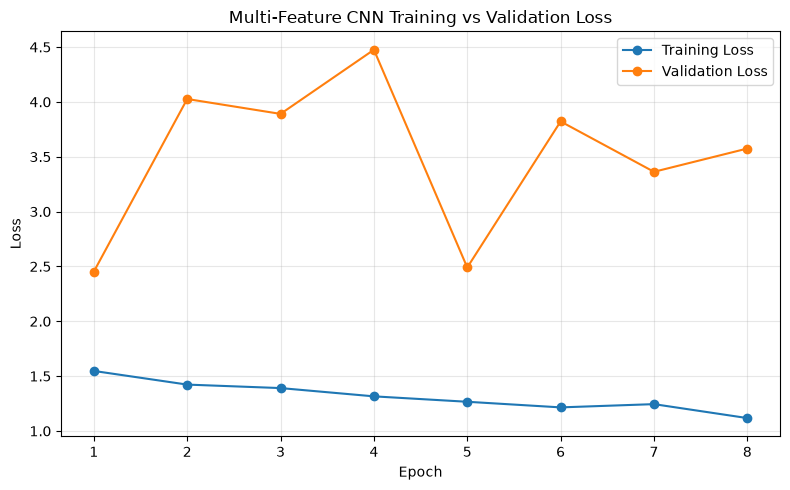

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-Feature CNN Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

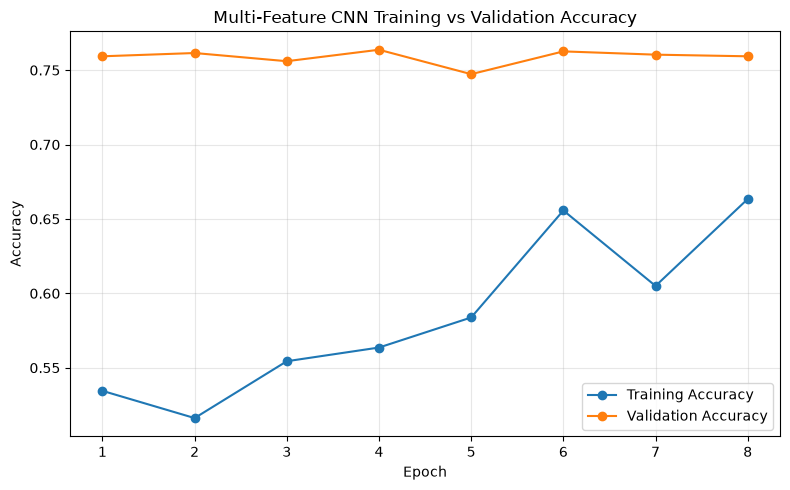

In [95]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-Feature CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-Feature CNN — Final Interpretation

The Multi-Feature CNN was developed to investigate whether combining three complementary
audio representations — Log-Mel spectrograms, MFCCs, and Chroma features — improves
respiratory disease classification compared with the lightweight Log-Mel CNN baseline.

The model used three independent CNN branches. Each branch learned a representation
from one feature type, after which the learned representations were concatenated and
passed to a fusion classifier.

The experiment used the same patient-disjoint train/validation/test partition as the
Lightweight Mel CNN to ensure a fair comparison between the two deep learning models.
Training-only augmentation consisted of Gaussian noise and random time shifting.
Class weights were calculated using training labels only.

The best model checkpoint was selected using validation loss rather than validation
accuracy. Training stopped early after validation loss failed to improve.

The final evaluation used the held-out test set and reported accuracy, balanced
accuracy, macro precision, macro recall, macro F1, weighted F1, and disease-level
performance.

Because the ICBHI disease distribution is highly imbalanced, accuracy and weighted F1
must be interpreted carefully. Balanced accuracy and macro F1 provide more useful
information about performance across disease classes.

The comparison with the Lightweight Mel CNN determines whether the additional MFCC
and Chroma representations provide a measurable benefit. If the Multi-Feature CNN
does not improve the balanced or macro-level metrics, the additional feature
representations do not demonstrate a clear advantage under the current experimental
configuration.

The results of this experiment are retained as an important Data Mining experiment,
rather than modifying the test set or repeatedly tuning against test performance.

**12B**


In [96]:
class RegularizedFeatureBranch(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, output_dim),
            nn.ReLU(),
            nn.Dropout(0.50)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.projection(x)
        return x

In [97]:
class RegularizedMultiFeatureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.logmel_branch = RegularizedFeatureBranch(
            output_dim=64
        )

        self.mfcc_branch = RegularizedFeatureBranch(
            output_dim=64
        )

        self.chroma_branch = RegularizedFeatureBranch(
            output_dim=64
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.50),

            nn.Linear(128, num_classes)
        )

    def forward(self, logmel, mfcc, chroma):

        logmel_features = self.logmel_branch(logmel)
        mfcc_features = self.mfcc_branch(mfcc)
        chroma_features = self.chroma_branch(chroma)

        fused_features = torch.cat(
            [
                logmel_features,
                mfcc_features,
                chroma_features
            ],
            dim=1
        )

        return self.classifier(fused_features)

In [98]:
model_12b = RegularizedMultiFeatureCNN(
    num_classes=num_classes
).to(device)

total_params_12b = sum(
    p.numel()
    for p in model_12b.parameters()
)

print("12B model created.")
print("Total parameters:", total_params_12b)

12B model created.
Total parameters: 108776


In [99]:
class_weights_tensor_12b = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion_12b = nn.CrossEntropyLoss(
    weight=class_weights_tensor_12b
)

print("12B weighted loss created.")

12B weighted loss created.


In [100]:
LEARNING_RATE_12B = 1e-4
WEIGHT_DECAY_12B = 1e-4

optimizer_12b = torch.optim.Adam(
    model_12b.parameters(),
    lr=LEARNING_RATE_12B,
    weight_decay=WEIGHT_DECAY_12B
)

print("12B learning rate:", LEARNING_RATE_12B)
print("12B weight decay:", WEIGHT_DECAY_12B)

12B learning rate: 0.0001
12B weight decay: 0.0001


In [101]:
LR_FACTOR_12B = 0.5
LR_PATIENCE_12B = 3
MIN_LR_12B = 1e-6

scheduler_12b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_12b,
    mode="min",
    factor=LR_FACTOR_12B,
    patience=LR_PATIENCE_12B,
    min_lr=MIN_LR_12B
)

print("12B scheduler created.")

12B scheduler created.


In [102]:
EXPERIMENT_12B_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deep_learning"
    / "multifeature_cnn_12b"
)

EXPERIMENT_12B_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_12B_PATH = (
    EXPERIMENT_12B_DIR
    / "best_regularized_multifeature_cnn.pt"
)

HISTORY_12B_PATH = (
    EXPERIMENT_12B_DIR
    / "training_history.csv"
)

CONFIG_12B_PATH = (
    EXPERIMENT_12B_DIR
    / "training_config.json"
)

print("12B output directory:")
print(EXPERIMENT_12B_DIR)

12B output directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn_12b


In [103]:
config_12b = {
    "experiment": "12B",
    "model": "Regularized Multi-Feature CNN",
    "features": [
        "Log-Mel",
        "MFCC",
        "Chroma"
    ],
    "patient_disjoint": True,
    "learning_rate": LEARNING_RATE_12B,
    "weight_decay": WEIGHT_DECAY_12B,
    "dropout_branch": 0.50,
    "dropout_classifier": 0.50,
    "max_epochs": 40,
    "early_stopping_patience": 7,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": LR_FACTOR_12B,
    "scheduler_patience": LR_PATIENCE_12B,
    "min_learning_rate": MIN_LR_12B,
    "loss": "weighted_cross_entropy",
    "augmentation": [
        "Gaussian noise",
        "Random time shift"
    ]
}

with open(CONFIG_12B_PATH, "w") as f:
    json.dump(
        config_12b,
        f,
        indent=4
    )

print("12B configuration saved.")

12B configuration saved.


In [104]:
history_12b = []

best_val_loss_12b = float("inf")
best_epoch_12b = 0
epochs_without_improvement_12b = 0

MAX_EPOCHS_12B = 40
EARLY_STOPPING_PATIENCE_12B = 7

print("Starting Experiment 12B...")

Starting Experiment 12B...


In [105]:
for epoch in range(1, MAX_EPOCHS_12B + 1):

    train_loss, train_accuracy = train_one_epoch(
        model_12b,
        train_loader,
        criterion_12b,
        optimizer_12b,
        device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model_12b,
        val_loader,
        criterion_12b,
        device
    )

    scheduler_12b.step(val_loss)

    current_lr = optimizer_12b.param_groups[0]["lr"]

    history_12b.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": val_loss,
        "validation_accuracy": val_accuracy,
        "learning_rate": current_lr
    })

    if val_loss < best_val_loss_12b:

        best_val_loss_12b = val_loss
        best_epoch_12b = epoch
        epochs_without_improvement_12b = 0

        torch.save(
            model_12b.state_dict(),
            BEST_MODEL_12B_PATH
        )

        improved = True

    else:
        epochs_without_improvement_12b += 1
        improved = False

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS_12B} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.2e}"
        + (" | BEST" if improved else "")
    )

    if (
        epochs_without_improvement_12b
        >= EARLY_STOPPING_PATIENCE_12B
    ):
        print(
            f"\nEarly stopping triggered at epoch {epoch}."
        )
        break

print("\n12B training completed.")
print("Best epoch:", best_epoch_12b)
print("Best validation loss:", best_val_loss_12b)

Epoch 01/40 | Train Loss: 2.0540 | Train Acc: 0.3346 | Val Loss: 1.7053 | Val Acc: 0.7615 | LR: 1.00e-04 | BEST
Epoch 02/40 | Train Loss: 1.9868 | Train Acc: 0.6543 | Val Loss: 1.3322 | Val Acc: 0.7615 | LR: 1.00e-04 | BEST
Epoch 03/40 | Train Loss: 1.8883 | Train Acc: 0.7115 | Val Loss: 1.4379 | Val Acc: 0.7615 | LR: 1.00e-04
Epoch 04/40 | Train Loss: 1.7921 | Train Acc: 0.6832 | Val Loss: 1.6483 | Val Acc: 0.7615 | LR: 1.00e-04
Epoch 05/40 | Train Loss: 1.6904 | Train Acc: 0.5808 | Val Loss: 1.5916 | Val Acc: 0.7615 | LR: 1.00e-04
Epoch 06/40 | Train Loss: 1.5992 | Train Acc: 0.5449 | Val Loss: 1.7801 | Val Acc: 0.7582 | LR: 5.00e-05
Epoch 07/40 | Train Loss: 1.5481 | Train Acc: 0.5790 | Val Loss: 1.7184 | Val Acc: 0.7549 | LR: 5.00e-05
Epoch 08/40 | Train Loss: 1.5192 | Train Acc: 0.5537 | Val Loss: 1.7222 | Val Acc: 0.7582 | LR: 5.00e-05
Epoch 09/40 | Train Loss: 1.5177 | Train Acc: 0.5605 | Val Loss: 1.7968 | Val Acc: 0.7571 | LR: 5.00e-05

Early stopping triggered at epoch 9.

12

In [106]:
history_12b_df = pd.DataFrame(history_12b)

history_12b_df.to_csv(
    HISTORY_12B_PATH,
    index=False
)

print("12B history saved:")
print(HISTORY_12B_PATH)

display(history_12b_df)

12B history saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn_12b/training_history.csv


,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,learning_rate
0,1,2.053983,0.334615,1.705282,0.761488,0.00010
1,2,1.986771,0.654307,1.332201,0.761488,0.00010
2,3,1.888308,0.711508,1.437939,0.761488,0.00010
3,4,1.792065,0.683247,1.648273,0.761488,0.00010
4,5,1.690389,0.580827,1.591629,0.761488,0.00010
5,6,1.599224,0.544879,1.780088,0.758206,0.00005
6,7,1.548077,0.579019,1.718374,0.754923,0.00005
7,8,1.519229,0.553697,1.722184,0.758206,0.00005
8,9,1.517712,0.560479,1.796830,0.757112,0.00005


In [107]:
best_model_12b = RegularizedMultiFeatureCNN(
    num_classes=num_classes
).to(device)

best_model_12b.load_state_dict(
    torch.load(
        BEST_MODEL_12B_PATH,
        map_location=device,
        weights_only=True
    )
)

best_model_12b.eval()

print("Best 12B checkpoint loaded.")
print("Best epoch:", best_epoch_12b)
print("Best validation loss:", best_val_loss_12b)

Best 12B checkpoint loaded.
Best epoch: 2
Best validation loss: 1.3322009372502501


In [108]:
y_test_true_12b = []
y_test_pred_12b = []
y_test_prob_12b = []

with torch.no_grad():

    for logmel, mfcc, chroma, labels in test_loader:

        logmel = logmel.to(device)
        mfcc = mfcc.to(device)
        chroma = chroma.to(device)

        outputs = best_model_12b(
            logmel,
            mfcc,
            chroma
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_test_true_12b.extend(
            labels.numpy()
        )

        y_test_pred_12b.extend(
            predictions.cpu().numpy()
        )

        y_test_prob_12b.extend(
            probabilities.cpu().numpy()
        )

y_test_true_12b = np.array(y_test_true_12b)
y_test_pred_12b = np.array(y_test_pred_12b)
y_test_prob_12b = np.array(y_test_prob_12b)

print("Test samples:", len(y_test_true_12b))

Test samples: 1561


In [109]:
accuracy_12b = accuracy_score(
    y_test_true_12b,
    y_test_pred_12b
)

balanced_accuracy_12b = balanced_accuracy_score(
    y_test_true_12b,
    y_test_pred_12b
)

macro_precision_12b = precision_score(
    y_test_true_12b,
    y_test_pred_12b,
    average="macro",
    zero_division=0
)

macro_recall_12b = recall_score(
    y_test_true_12b,
    y_test_pred_12b,
    average="macro",
    zero_division=0
)

macro_f1_12b = f1_score(
    y_test_true_12b,
    y_test_pred_12b,
    average="macro",
    zero_division=0
)

weighted_f1_12b = f1_score(
    y_test_true_12b,
    y_test_pred_12b,
    average="weighted",
    zero_division=0
)

print("=== Experiment 12B Test Metrics ===")
print(f"Accuracy:          {accuracy_12b:.6f}")
print(f"Balanced Accuracy: {balanced_accuracy_12b:.6f}")
print(f"Macro Precision:   {macro_precision_12b:.6f}")
print(f"Macro Recall:      {macro_recall_12b:.6f}")
print(f"Macro F1:          {macro_f1_12b:.6f}")
print(f"Weighted F1:       {weighted_f1_12b:.6f}")

=== Experiment 12B Test Metrics ===
Accuracy:          0.856502
Balanced Accuracy: 0.166667
Macro Precision:   0.142750
Macro Recall:      0.166667
Macro F1:          0.153784
Weighted F1:       0.790299


In [110]:
report_12b = classification_report(
    y_test_true_12b,
    y_test_pred_12b,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
)

print(report_12b)

                precision    recall  f1-score   support

        Asthma       0.00      0.00      0.00         0
Bronchiectasis       0.00      0.00      0.00        20
 Bronchiolitis       0.00      0.00      0.00        19
          COPD       0.86      1.00      0.92      1337
       Healthy       0.00      0.00      0.00        84
          LRTI       0.00      0.00      0.00         0
     Pneumonia       0.00      0.00      0.00        52
          URTI       0.00      0.00      0.00        49

      accuracy                           0.86      1561
     macro avg       0.11      0.12      0.12      1561
  weighted avg       0.73      0.86      0.79      1561



In [111]:
cm_12b = confusion_matrix(
    y_test_true_12b,
    y_test_pred_12b,
    labels=np.arange(num_classes)
)

cm_12b_df = pd.DataFrame(
    cm_12b,
    index=class_names,
    columns=class_names
)

display(cm_12b_df)

,Asthma,Bronchiectasis,Bronchiolitis,COPD,Healthy,LRTI,Pneumonia,URTI
Asthma,0,0,0,0,0,0,0,0
Bronchiectasis,0,0,0,20,0,0,0,0
Bronchiolitis,0,0,0,19,0,0,0,0
COPD,0,0,0,1337,0,0,0,0
Healthy,0,0,0,84,0,0,0,0
LRTI,0,0,0,0,0,0,0,0
Pneumonia,0,0,0,52,0,0,0,0
URTI,0,0,0,49,0,0,0,0


In [112]:
metrics_12b_df = pd.DataFrame([{
    "model": "Regularized Multi-Feature CNN (12B)",
    "best_epoch": best_epoch_12b,
    "best_validation_loss": best_val_loss_12b,
    "test_samples": len(y_test_true_12b),
    "accuracy": accuracy_12b,
    "balanced_accuracy": balanced_accuracy_12b,
    "macro_precision": macro_precision_12b,
    "macro_recall": macro_recall_12b,
    "macro_f1": macro_f1_12b,
    "weighted_f1": weighted_f1_12b
}])

METRICS_12B_PATH = (
    EXPERIMENT_12B_DIR
    / "metrics.csv"
)

metrics_12b_df.to_csv(
    METRICS_12B_PATH,
    index=False
)

cm_12b_df.to_csv(
    EXPERIMENT_12B_DIR
    / "confusion_matrix.csv"
)

predictions_12b_df = pd.DataFrame({
    "true_label": y_test_true_12b,
    "predicted_label": y_test_pred_12b
})

for idx, class_name in enumerate(class_names):
    predictions_12b_df[
        f"prob_{class_name}"
    ] = y_test_prob_12b[:, idx]

predictions_12b_df.to_csv(
    EXPERIMENT_12B_DIR
    / "test_predictions.csv",
    index=False
)

print("12B results saved.")

12B results saved.


In [113]:
# Load Notebook 11 metrics
baseline_metrics = pd.read_csv(
    BASELINE_DIR / "cnn_baseline_metrics.csv"
)

# Load Notebook 12A metrics
metrics_12a = pd.read_csv(
    MULTIFEATURE_DIR / "multifeature_cnn_metrics.csv"
)

# 12B metrics should already exist
metrics_12b = pd.read_csv(
    EXPERIMENT_12B_DIR / "metrics.csv"
)

final_cnn_comparison = pd.DataFrame([
    {
        "model": "Lightweight Mel CNN",
        "features": "Log-Mel",
        "accuracy": baseline_metrics["accuracy"].iloc[0],
        "balanced_accuracy": baseline_metrics["balanced_accuracy"].iloc[0],
        "macro_precision": baseline_metrics["macro_precision"].iloc[0],
        "macro_recall": baseline_metrics["macro_recall"].iloc[0],
        "macro_f1": baseline_metrics["macro_f1"].iloc[0],
        "weighted_f1": baseline_metrics["weighted_f1"].iloc[0]
    },
    {
        "model": "Multi-Feature CNN 12A",
        "features": "Log-Mel + MFCC + Chroma",
        "accuracy": metrics_12a["accuracy"].iloc[0],
        "balanced_accuracy": metrics_12a["balanced_accuracy"].iloc[0],
        "macro_precision": metrics_12a["macro_precision"].iloc[0],
        "macro_recall": metrics_12a["macro_recall"].iloc[0],
        "macro_f1": metrics_12a["macro_f1"].iloc[0],
        "weighted_f1": metrics_12a["weighted_f1"].iloc[0]
    },
    {
        "model": "Regularized Multi-Feature CNN 12B",
        "features": "Log-Mel + MFCC + Chroma",
        "accuracy": metrics_12b["accuracy"].iloc[0],
        "balanced_accuracy": metrics_12b["balanced_accuracy"].iloc[0],
        "macro_precision": metrics_12b["macro_precision"].iloc[0],
        "macro_recall": metrics_12b["macro_recall"].iloc[0],
        "macro_f1": metrics_12b["macro_f1"].iloc[0],
        "weighted_f1": metrics_12b["weighted_f1"].iloc[0]
    }
])

display(final_cnn_comparison)

,model,features,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Lightweight Mel CNN,Log-Mel,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,Multi-Feature CNN 12A,Log-Mel + MFCC + Chroma,0.855221,0.166417,0.142720,0.166417,0.153660,0.789662
2,Regularized Multi-Feature CNN 12B,Log-Mel + MFCC + Chroma,0.856502,0.166667,0.142750,0.166667,0.153784,0.790299


In [114]:
ranking_df = final_cnn_comparison.sort_values(
    by=["macro_f1", "balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

ranking_df.insert(
    0,
    "rank",
    np.arange(1, len(ranking_df) + 1)
)

display(ranking_df)

,rank,model,features,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,Lightweight Mel CNN,Log-Mel,0.716848,0.310168,0.213023,0.265858,0.212880,0.768721
1,2,Regularized Multi-Feature CNN 12B,Log-Mel + MFCC + Chroma,0.856502,0.166667,0.142750,0.166667,0.153784,0.790299
2,3,Multi-Feature CNN 12A,Log-Mel + MFCC + Chroma,0.855221,0.166417,0.142720,0.166417,0.153660,0.789662


In [115]:
FINAL_CNN_COMPARISON_PATH = (
    MULTIFEATURE_DIR
    / "final_cnn_experiment_comparison.csv"
)

ranking_df.to_csv(
    FINAL_CNN_COMPARISON_PATH,
    index=False
)

print("Final CNN comparison saved:")
print(FINAL_CNN_COMPARISON_PATH)

Final CNN comparison saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/final_cnn_experiment_comparison.csv


In [116]:
best_cnn_row = ranking_df.iloc[0]

best_cnn_name = best_cnn_row["model"]

print("=== Best CNN According to Macro F1 ===")
print("Model:", best_cnn_name)
print("Balanced Accuracy:",
      f"{best_cnn_row['balanced_accuracy']:.6f}")
print("Macro F1:",
      f"{best_cnn_row['macro_f1']:.6f}")
print("Weighted F1:",
      f"{best_cnn_row['weighted_f1']:.6f}")

=== Best CNN According to Macro F1 ===
Model: Lightweight Mel CNN
Balanced Accuracy: 0.310168
Macro F1: 0.212880
Weighted F1: 0.768721


In [117]:
notebook12_summary = {
    "notebook": "12_multifeature_cnn",

    "experiments": [
        "12A - Multi-Feature CNN",
        "12B - Regularized Multi-Feature CNN"
    ],

    "baseline_comparison": "11 - Lightweight Mel CNN",

    "input_features": [
        "Log-Mel",
        "MFCC",
        "Chroma"
    ],

    "patient_disjoint": True,

    "selection_priority": [
        "Macro F1",
        "Balanced Accuracy"
    ],

    "best_cnn": best_cnn_name,

    "12A_best_epoch": int(
        metrics_12a["best_epoch"].iloc[0]
    ),

    "12B_best_epoch": int(
        metrics_12b["best_epoch"].iloc[0]
    ),

    "results_file": str(
        FINAL_CNN_COMPARISON_PATH
    )
}

SUMMARY_12_PATH = (
    MULTIFEATURE_DIR
    / "notebook12_experiment_summary.json"
)

with open(SUMMARY_12_PATH, "w") as f:
    json.dump(
        notebook12_summary,
        f,
        indent=4
    )

print("Notebook 12 summary saved:")
print(SUMMARY_12_PATH)

Notebook 12 summary saved:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/multifeature_cnn/notebook12_experiment_summary.json


# Final Conclusion — Notebook 12

Notebook 12 investigated multi-feature deep learning for respiratory disease
classification using Log-Mel spectrograms, MFCCs, and Chroma features.

A three-branch CNN architecture was used so that each representation could be
processed independently before feature fusion.

Two multi-feature experiments were performed:

- **12A — Multi-Feature CNN:** original training configuration.
- **12B — Regularized Multi-Feature CNN:** lower learning rate and stronger dropout
  to address the rapid validation-loss deterioration observed in 12A.

Both experiments used the same patient-disjoint train/validation/test split,
training-only augmentation, training-only class-weight calculation, and the same
held-out test set.

## Experimental Finding

The original Multi-Feature CNN (12A) achieved higher raw accuracy than the
Lightweight Mel CNN, but its balanced accuracy and macro F1 were lower. Its
improved accuracy was primarily associated with stronger performance on the
dominant COPD class, while minority disease classes remained poorly recognized.

The regularized 12B experiment was therefore introduced as a controlled
improvement rather than changing the dataset or evaluation procedure.

Model selection prioritizes **macro F1** and **balanced accuracy** because the
ICBHI disease distribution is highly imbalanced. Accuracy and weighted F1 are
reported as supplementary metrics.

The final comparison between the Lightweight Mel CNN, Multi-Feature CNN 12A,
and Regularized Multi-Feature CNN 12B is saved in:

`final_cnn_experiment_comparison.csv`

The experiment demonstrates an important Data Mining principle: adding more
features does not automatically produce better classification performance.
Feature integration must be evaluated empirically using metrics appropriate
for the class distribution.

The selected CNN model will be carried forward for comparison with subsequent
experiments such as the optional CNN-LSTM architecture and patient-level
prediction.